# Feature Extraction notebook
we are continuing the EDA process with the feature extraction of the Data we made in the first notebook. In the first notebook we created the CSV and metadata table. Before the start of this notebook I made a featureextraction.py that goes through and gets all of the features outlined in github. There was MFCC, MFCC delta, MFCC delta 2, Chroma, Mel spectogram, RMS, Centroid, Bandwidth, ZCR, and rolloff. For each feature we have the mean, std, min, and max

In [8]:
#Imports
from pathlib import Path   
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
# Audio
import librosa
import librosa.display

# Always run from SER_Project/ regardless of where the notebook lives
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())

Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


Now that we have everything setup in the imports, our first job will be to run the build_feature_table method which utilized our metadata.csv. It will create a dataframe of all of the features and then also create a .csv at our /data/processed/features.csv

In [3]:
from minilearn.featureextraction import build_feature_table

# Comment this line out after the first run so you don't re-extract every
# time you restart the kernel
features = build_feature_table()

Loaded metadata with 2452 rows


Extracting features:   0%|          | 0/2452 [00:00<?, ?it/s]c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting features:  85%|████████▍ | 2080/2452 [02:16<00:25, 14.83it/s]c:\Users\bradd\Project_CSE432-532\SER_Project\minilearn\featureextraction.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(str(wav_path), sr=SAMPLE_RATE)
c:\Users\bradd\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Extracting features:  85%|████████▍ | 2083/2452 [02:16<00:21, 17.33it/s]

Skipping bad file


Extracting features: 100%|██████████| 2452/2452 [02:40<00:00, 15.24it/s]



Saved features to: data/processed/features.csv
Shape: (2451, 496)


As you can see after we run it, we get all of our original data points minus one. The shape gives us 2451 rows followed by 496 columns with 480 of those being different features. below lets just make sure again that everything is setup as we want it.

In [5]:
print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


Now that we have the entire new dataframe loaded with the features it is time to go and do the analysis that you have put on github. Those being the correlation analysis, feature distribution by emotion, and visualizations. I will go one by one in the cells below

The first thing we are going to do below is feature distribution by emotion. A lot of the different features looked almost un-interaple by just looking at it. These six have been cherry picked because they are easy to see the differences between different emotions. 

With the MFCC_1_mean you can see the angry emotion has the highest mean followed by fearful and happy. All three have large whiskers, and happy and fearful looks to have outliers which will be removed when features are standerized. In the ZRC mean you can see the natural curve going from nutral and peaking around angry while coming back down around surprised. This graph is full of outliers across the board. The RMS_mean graph is full of outliers across every single emotion however again as in a lot of these graphs you see this pattern with angry happy and fearful having higher means in the box and whisker plots. for the Spec centroid graph, spec rolloff graph, and chroma 1 box plot you can see they somehow mimic the opposite of the first 3 graphs. The dip is around angry, fearful, and happy while outside like surprised and nuetral have the highest means in the whisker plots.

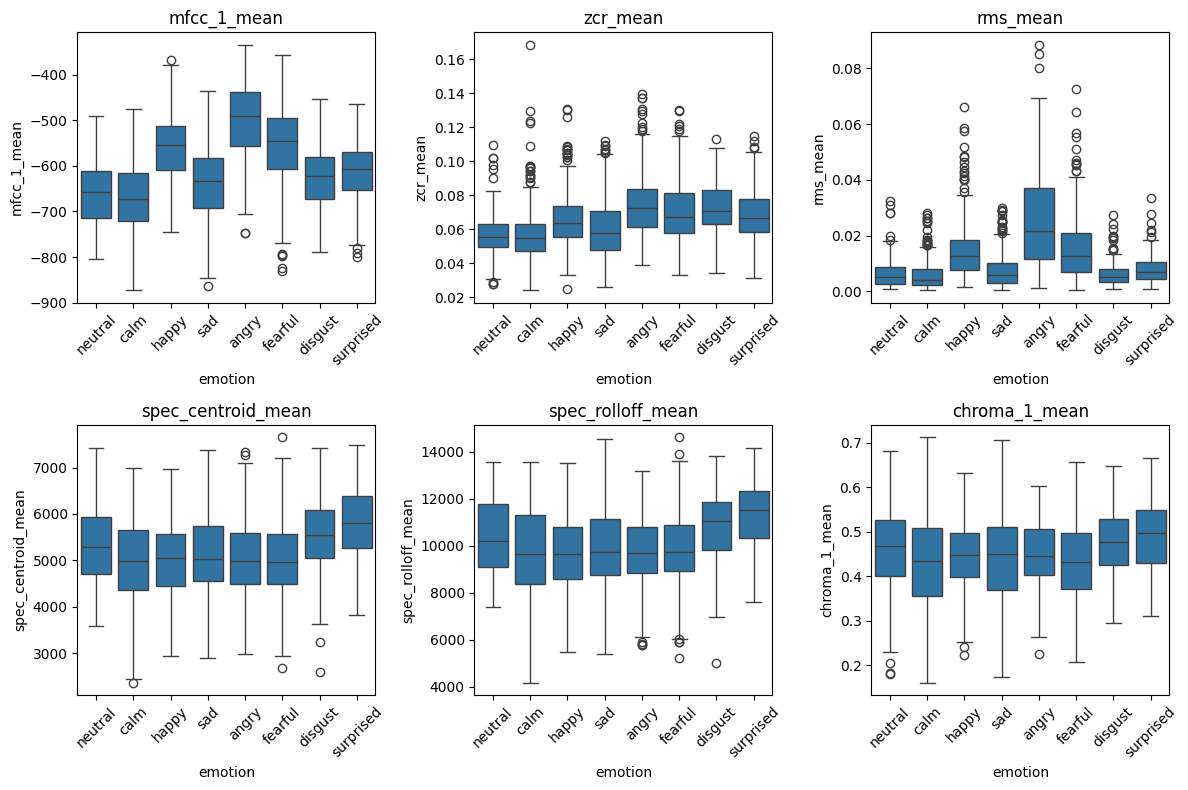

rms_mean                                                    \
             count      mean       std       min       25%       50%   
emotion                                                                
angry        376.0  0.026199  0.017738  0.001283  0.011739  0.021677   
calm         376.0  0.005696  0.005004  0.000445  0.002079  0.003870   
disgust      191.0  0.006156  0.004386  0.000800  0.003207  0.004992   
fearful      376.0  0.015218  0.011241  0.000489  0.006864  0.012568   
happy        376.0  0.014723  0.010214  0.001634  0.007495  0.012613   
neutral      188.0  0.006472  0.005382  0.000893  0.002446  0.004955   
sad          376.0  0.007538  0.005992  0.000328  0.003137  0.005747   
surprised    192.0  0.008045  0.005117  0.000854  0.004374  0.006974   

                              zcr_mean            ... spec_rolloff_mean  \
                75%       max    count      mean  ...               75%   
emotion                                           ...                     
angry      0.036879  0.088503    376.0  0.073973  ...      10811.338289   
calm       0.007863  0.027972    376.0  0.056520  ...      11297.217856   
disgust    0.007830  0.027260    191.0  0.073596  ...      11878.662584   
fearful    0.020929  0.072525    376.0  0.070437  ...      10885.880194   
happy      0.018399  0.065952    376.0  0.065909  ...      10808.610916   
neutral    0.008644  0.032391    188.0  0.057340  ...      11788.259220   
sad        0.010162  0.029887    376.0  0.060726  ...      11128.268134   
surprised  0.010329  0.033458    192.0  0.068609  ...      12336.765285   

                        chroma_1_mean                                          \
                    max         count      mean       std       min       25%   
emotion                                                                         
angry      13204.687500         376.0  0.450933  0.072308  0.225738  0.402992   
calm       13588.320035         376.0  0.432575  0.106124  0.160283  0.356381   
disgust    13822.583866         191.0  0.478129  0.074175  0.294100  0.425767   
fearful    14629.598497         376.0  0.434961  0.089297  0.207205  0.372091   
happy      13510.801630         376.0  0.446776  0.074532  0.222261  0.397344   
neutral    13564.194915         188.0  0.457197  0.101034  0.181023  0.400638   
sad        14557.735101         376.0  0.439219  0.100364  0.174515  0.368444   
surprised  14149.007161         192.0  0.489356  0.072794  0.310999  0.430272   

                                         
                50%       75%       max  
emotion                                  
angry      0.446270  0.505591  0.602428  
calm       0.433434  0.509646  0.713219  
disgust    0.476949  0.529806  0.647665  
fearful    0.432199  0.496547  0.656939  
happy      0.448380  0.497539  0.632158  
neutral    0.468784  0.526490  0.682905  
sad        0.449276  0.510502  0.706292  
surprised  0.496887  0.549053  0.667230  

[8 rows x 48 columns]

In [17]:
features_to_plot = ["mfcc_1_mean", "zcr_mean", "rms_mean", "spec_centroid_mean", "spec_rolloff_mean","chroma_1_mean"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, feat in zip(axes.flat, features_to_plot):
    sns.boxplot(data=features, x="emotion", y=feat, ax=ax)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

features.groupby("emotion")[["rms_mean", "zcr_mean", "spec_centroid_mean", "mfcc_1_mean","spec_rolloff_mean","chroma_1_mean" ]].describe()

Now that we have the feature distribution by emotion, we are going to do the correlation analysis between the different features. It looks like to be able to accomplish this I will have to go through and drop the columns that are categorical and only keep the features. Since MFCC and the deltas have thirteen I had to take the first one, I also took the first out of the chroma. I decided to leave the melspectogram out because it has a range of 64 * 4 so I feel like just taking one dosen't show the actual value of a correlation matrix

                     mfcc_1_mean  mfcc_delta_1_mean  mfcc_delta2_1_mean  \
mfcc_1_mean             1.000000          -0.136202           -0.036084   
mfcc_delta_1_mean      -0.136202           1.000000            0.083542   
mfcc_delta2_1_mean     -0.036084           0.083542            1.000000   
chroma_1_mean          -0.252048           0.075253            0.027091   
zcr_mean                0.412003          -0.051830           -0.076944   
rms_mean                0.861309          -0.087430           -0.019637   
spec_centroid_mean     -0.371787           0.075363            0.007755   
spec_bandwidth_mean    -0.354667           0.059818            0.040729   
spec_rolloff_mean      -0.379988           0.072129            0.020899   

                     chroma_1_mean  zcr_mean  rms_mean  spec_centroid_mean  \
mfcc_1_mean              -0.252048  0.412003  0.861309           -0.371787   
mfcc_delta_1_mean         0.075253 -0.051830 -0.087430            0.075363   
mfcc_delta2_1_m

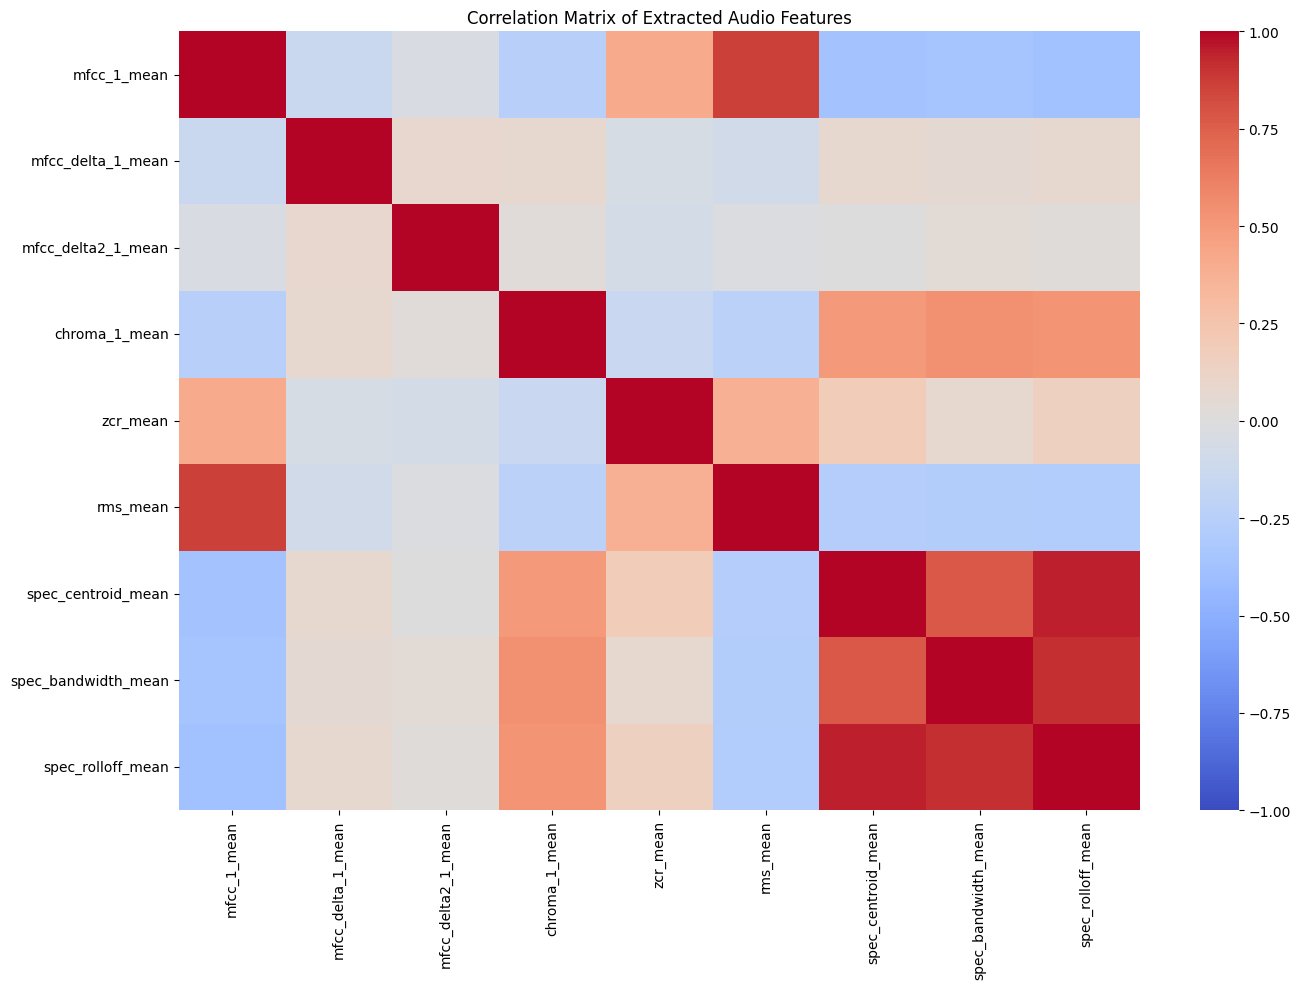

In [ ]:
correlation_categories = ["mfcc_1_mean", "mfcc_delta_1_mean", "mfcc_delta2_1_mean","chroma_1_mean","zcr_mean", "rms_mean", "spec_centroid_mean","spec_bandwidth_mean", "spec_rolloff_mean",]

mean_features = features[correlation_categories]

corr_matrix = mean_features.corr()

print(corr_matrix)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Extracted Audio Features")
plt.tight_layout()
plt.show()



The correlation matrix looks very similar to other matricies. You have the lind down the middle which is highly correlated and then the square at the bottom right of the graph which is also typical. However lets dive into some of the untypical results. First the MFCC_1_meam seems to be pretty correlated to the ZCR mean and the ZCR mean which is suspicious to me. there also seems to be a lot of grey around the correlation map which seems to shows not a lot of correlation overall. Another piece of correclation is between chroma 1 and Spec_centroid_mean, Spec_bandwith_mean, and Spec_rolloff_mean

Now that we have both the feature distributions and the correlation matrix it is time to move onto the feature standarization. I will be completing this inside of minilearn as part of the process of preprocessing